# 1. Check Quality Task Notebook

Notebook nay chuyen plan `Data Understanding -> Check Quality -> Initial EDA` thanh cac cell co the chay duoc.

Pham vi quan trong:
- Day la EDA dau ky tren du lieu goc, metric goc va cac join can thiet da duoc kiem soat.
- Day khong phai EDA so so. Muc tieu la hieu sau du lieu hien co truoc khi clean/feature engineering/modeling.
- Chua clean manh tay, chua tao feature modeling, chua train model.
- Neu co bat thuong, notebook ghi nhan va tao bang canh bao de quyet dinh sau trong Data Preparation.


## 0. Setup

Cell nay khai bao thu vien, duong dan va cac helper dung lai nhieu lan. Output se duoc luu vao `report_3_6_2026/quality_outputs` de tach voi data goc.

In [35]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 160)

sns.set_theme(style='whitegrid')

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'report_3_6_2026' else Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'data'
REPORT_DIR = PROJECT_DIR / 'report_3_6_2026'
OUTPUT_DIR = REPORT_DIR / 'quality_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('DATA_DIR:', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_DIR: B:\Dự án VSF\VinuniDatathon
DATA_DIR: B:\Dự án VSF\VinuniDatathon\data
OUTPUT_DIR: B:\Dự án VSF\VinuniDatathon\report_3_6_2026\quality_outputs


## 1. Data Understanding

Muc tieu: lap ban do du lieu nhieu bang truoc khi check loi. Voi du an nhieu bang, day la buoc bat buoc de tranh join sai grain.

In [36]:
csv_paths = sorted(DATA_DIR.glob('*.csv'))
csv_paths


[WindowsPath('B:/Dự án VSF/VinuniDatathon/data/customers.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/geography.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/inventory.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/order_items.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/orders.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/payments.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/products.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/promotions.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/returns.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/reviews.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/sales.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/sample_submission.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/shipments.csv'),
 WindowsPath('B:/Dự án VSF/VinuniDatathon/data/web_traffic.csv')]

In [37]:
tables = {}

for path in csv_paths:
    name = path.stem
    tables[name] = pd.read_csv(path)
    print(f'{name:18s} shape={tables[name].shape}')



customers          shape=(121930, 7)
geography          shape=(39948, 4)
inventory          shape=(60247, 17)
order_items        shape=(714669, 7)
orders             shape=(646945, 8)
payments           shape=(646945, 4)
products           shape=(2412, 8)
promotions         shape=(50, 10)
returns            shape=(39939, 7)
reviews            shape=(113551, 7)
sales              shape=(3833, 3)
sample_submission  shape=(548, 3)
shipments          shape=(566067, 4)
web_traffic        shape=(3652, 7)


In [38]:
def table_inventory(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, df in tables.items():
        rows.append({
            'table': name,
            'n_rows': len(df),
            'n_cols': df.shape[1],
            'memory_mb': df.memory_usage(deep=True).sum() / 1024**2,
            'duplicate_full_rows': int(df.duplicated().sum()),
            'columns': ', '.join(df.columns),
        })
    return pd.DataFrame(rows).sort_values(['n_rows', 'table'], ascending=[False, True])

inventory_df = table_inventory(tables)
inventory_df.to_csv(OUTPUT_DIR / '01_table_inventory.csv', index=False)
inventory_df


,table,n_rows,n_cols,memory_mb,duplicate_full_rows,columns
3,order_items,714669,7,78.002741,0,"order_id, product_id, quantity, unit_price, di..."
4,orders,646945,8,194.241660,0,"order_id, order_date, customer_id, zip, order_..."
5,payments,646945,4,50.563536,0,"order_id, payment_method, payment_value, insta..."
12,shipments,566067,4,72.339163,0,"order_id, ship_date, delivery_date, shipping_fee"
0,customers,121930,7,34.979523,0,"customer_id, zip, city, signup_date, gender, a..."
9,reviews,113551,7,23.279181,0,"review_id, order_id, product_id, customer_id, ..."
2,inventory,60247,17,19.686709,0,"snapshot_date, product_id, stock_on_hand, unit..."
1,geography,39948,4,6.863531,0,"zip, city, region, district"
8,returns,39939,7,8.017915,0,"return_id, order_id, product_id, return_date, ..."
10,sales,3833,3,0.274283,0,"Date, Revenue, COGS"


### 1.1. Grain hypothesis

Bang duoi la gia thuyet grain ban dau. Day khong phai ket luan cuoi. Cac cell sau se kiem tra bang unique key va duplicate key.

In [39]:
grain_hypothesis = {
    'customers': {'grain': '1 dong = 1 customer', 'candidate_key': ['customer_id']},
    'geography': {'grain': '1 dong = 1 dia diem/zip-city', 'candidate_key': ['zip']},
    'products': {'grain': '1 dong = 1 product', 'candidate_key': ['product_id']},
    'promotions': {'grain': '1 dong = 1 promotion', 'candidate_key': ['promo_id']},
    'orders': {'grain': '1 dong = 1 order', 'candidate_key': ['order_id']},
    'order_items': {'grain': '1 dong = 1 item/product trong order; can verify vi khong co order_item_id', 'candidate_key': ['order_id', 'product_id']},
    'payments': {'grain': '1 dong = 1 payment theo order; can verify co nhieu payment/order khong', 'candidate_key': ['order_id']},
    'shipments': {'grain': '1 dong = 1 shipment theo order; can verify co nhieu shipment/order khong', 'candidate_key': ['order_id']},
    'returns': {'grain': '1 dong = 1 return event', 'candidate_key': ['return_id']},
    'reviews': {'grain': '1 dong = 1 review', 'candidate_key': ['review_id']},
    'inventory': {'grain': '1 dong = 1 product tai 1 snapshot_date', 'candidate_key': ['snapshot_date', 'product_id']},
    'sales': {'grain': '1 dong = 1 ngay trong target sales', 'candidate_key': ['Date']},
    'web_traffic': {'grain': '1 dong = 1 ngay traffic', 'candidate_key': ['date']},
    'sample_submission': {'grain': '1 dong = 1 ngay can du doan', 'candidate_key': ['Date']},
}

grain_df = pd.DataFrame([
    {'table': table, 'grain_hypothesis': spec['grain'], 'candidate_key': ', '.join(spec['candidate_key'])}
    for table, spec in grain_hypothesis.items()
    if table in tables
])
grain_df.to_csv(OUTPUT_DIR / '02_grain_hypothesis.csv', index=False)
grain_df


,table,grain_hypothesis,candidate_key
0,customers,1 dong = 1 customer,customer_id
1,geography,1 dong = 1 dia diem/zip-city,zip
2,products,1 dong = 1 product,product_id
3,promotions,1 dong = 1 promotion,promo_id
4,orders,1 dong = 1 order,order_id
5,order_items,1 dong = 1 item/product trong order; can verif...,"order_id, product_id"
6,payments,1 dong = 1 payment theo order; can verify co n...,order_id
7,shipments,1 dong = 1 shipment theo order; can verify co ...,order_id
8,returns,1 dong = 1 return event,return_id
9,reviews,1 dong = 1 review,review_id


## 2. Check Quality

Muc tieu: phat hien rui ro, chua clean. Moi bat thuong can duoc dien giai theo anh huong den metric, join, target hoac model.

In [40]:
def column_profile(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for table, df in tables.items():
        for col in df.columns:
            s = df[col]
            rows.append({
                'table': table,
                'column': col,
                'dtype': str(s.dtype),
                'n_rows': len(s),
                'missing_count': int(s.isna().sum()),
                'missing_pct': float(s.isna().mean()),
                'n_unique': int(s.nunique(dropna=True)),
                'unique_pct': float(s.nunique(dropna=True) / max(len(s), 1)),
                'sample_values': ', '.join(map(str, s.dropna().astype(str).unique()[:5])),
            })
    return pd.DataFrame(rows)

profile_df = column_profile(tables)
profile_df.to_csv(OUTPUT_DIR / '03_column_profile.csv', index=False)
profile_df.sort_values(['missing_pct', 'table', 'column'], ascending=[False, True, True]).head(30)


,table,column,dtype,n_rows,missing_count,missing_pct,n_unique,unique_pct,sample_values
34,order_items,promo_id_2,str,714669,714463,0.999712,2,0.000003,"PROMO-0015, PROMO-0025"
61,promotions,applicable_category,str,50,40,0.800000,2,0.040000,"Streetwear, Outdoor"
33,order_items,promo_id,str,714669,438353,0.613365,50,0.000070,"PROMO-0006, PROMO-0001, PROMO-0002, PROMO-0005..."
6,customers,acquisition_channel,str,121930,0,0.000000,6,0.000049,"social_media, email_campaign, organic_search, ..."
5,customers,age_group,str,121930,0,0.000000,5,0.000041,"35-44, 45-54, 18-24, 55+, 25-34"
2,customers,city,str,121930,0,0.000000,42,0.000344,"Hai Phong, Phu Ly, Viet Tri, Bac Giang, Lao Cai"
0,customers,customer_id,int64,121930,0,0.000000,121930,1.000000,"1, 2, 3, 4, 5"
4,customers,gender,str,121930,0,0.000000,3,0.000025,"Female, Male, Non-binary"
3,customers,signup_date,str,121930,0,0.000000,3941,0.032322,"2021-12-30, 2013-12-27, 2018-07-24, 2017-11-29..."
1,customers,zip,int64,121930,0,0.000000,31491,0.258271,"15201, 15202, 15203, 15204, 15205"


In [41]:
def check_candidate_keys(tables: dict[str, pd.DataFrame], grain_hypothesis: dict) -> pd.DataFrame:
    rows = []
    for table, spec in grain_hypothesis.items():
        if table not in tables:
            continue
        df = tables[table]
        keys = spec['candidate_key']
        missing_keys = [k for k in keys if k not in df.columns]
        if missing_keys:
            rows.append({'table': table, 'candidate_key': ', '.join(keys), 'status': 'missing_key_column', 'duplicate_key_rows': np.nan, 'unique_key_count': np.nan, 'n_rows': len(df)})
            continue
        dup_count = int(df.duplicated(keys).sum())
        rows.append({
            'table': table,
            'candidate_key': ', '.join(keys),
            'status': 'unique' if dup_count == 0 else 'has_duplicate_key',
            'duplicate_key_rows': dup_count,
            'unique_key_count': int(df[keys].drop_duplicates().shape[0]),
            'n_rows': len(df),
            'duplicate_key_pct': dup_count / max(len(df), 1),
            'grain_hypothesis': spec['grain'],
        })
    return pd.DataFrame(rows)

key_check_df = check_candidate_keys(tables, grain_hypothesis)
key_check_df.to_csv(OUTPUT_DIR / '04_candidate_key_check.csv', index=False)
key_check_df


,table,candidate_key,status,duplicate_key_rows,unique_key_count,n_rows,duplicate_key_pct,grain_hypothesis
0,customers,customer_id,unique,0,121930,121930,0.000000,1 dong = 1 customer
1,geography,zip,unique,0,39948,39948,0.000000,1 dong = 1 dia diem/zip-city
2,products,product_id,unique,0,2412,2412,0.000000,1 dong = 1 product
3,promotions,promo_id,unique,0,50,50,0.000000,1 dong = 1 promotion
4,orders,order_id,unique,0,646945,646945,0.000000,1 dong = 1 order
5,order_items,"order_id, product_id",has_duplicate_key,16,714653,714669,0.000022,1 dong = 1 item/product trong order; can verif...
6,payments,order_id,unique,0,646945,646945,0.000000,1 dong = 1 payment theo order; can verify co n...
7,shipments,order_id,unique,0,566067,566067,0.000000,1 dong = 1 shipment theo order; can verify co ...
8,returns,return_id,unique,0,39939,39939,0.000000,1 dong = 1 return event
9,reviews,review_id,unique,0,113551,113551,0.000000,1 dong = 1 review


In [42]:
def duplicate_examples(df: pd.DataFrame, keys: list[str], n=20) -> pd.DataFrame:
    if not all(k in df.columns for k in keys):
        return pd.DataFrame()
    mask = df.duplicated(keys, keep=False)
    return df.loc[mask].sort_values(keys).head(n)

for _, row in key_check_df.query("status == 'has_duplicate_key'").iterrows():
    table = row['table']
    keys = [x.strip() for x in row['candidate_key'].split(',')]
    print('\n===', table, '| duplicate candidate key:', keys, '===')
    display(duplicate_examples(tables[table], keys, n=10))



=== order_items | duplicate candidate key: ['order_id', 'product_id'] ===


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
12233,14280,976,1,4019.47,0.00,NaN,NaN
12234,14280,976,2,3937.99,0.00,NaN,NaN
99645,113379,786,6,694.34,0.00,NaN,NaN
99646,113379,786,1,699.37,0.00,NaN,NaN
189239,215525,1859,5,1896.11,0.00,NaN,NaN
189240,215525,1859,5,1897.20,0.00,NaN,NaN
190291,216740,791,8,793.10,0.00,NaN,NaN
190292,216740,791,5,825.52,0.00,NaN,NaN
214311,243342,777,7,1181.17,1653.64,PROMO-0010,NaN
214312,243342,777,5,1147.21,1147.21,PROMO-0010,NaN


### 2.1. Kiem tra ngoai lai va gia tri cuc tri

Muc tieu phan nay la phat hien numeric outlier va kiem tra xem outlier co hop ly ve nghiep vu khong. Khong xoa outlier o day. Vi du tien cao thi can xem quantity, COGS, margin, discount, category de phan biet don lon hop ly voi loi du lieu.

In [ ]:
def numeric_outlier_summary(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for table, df in tables.items():
        numeric_cols = df.select_dtypes(include='number').columns.tolist()
        for col in numeric_cols:
            x = pd.to_numeric(df[col], errors='coerce').dropna()
            if len(x) == 0:
                continue
            q01, q25, q50, q75, q99 = x.quantile([0.01, 0.25, 0.50, 0.75, 0.99])
            iqr = q75 - q25
            lower = q25 - 1.5 * iqr
            upper = q75 + 1.5 * iqr
            rows.append({
                'table': table,
                'column': col,
                'n_non_missing': len(x),
                'min': x.min(),
                'q01': q01,
                'q25': q25,
                'median': q50,
                'q75': q75,
                'q99': q99,
                'max': x.max(),
                'iqr': iqr,
                'lower_iqr_bound': lower,
                'upper_iqr_bound': upper,
                'low_outlier_count': int((x < lower).sum()),
                'high_outlier_count': int((x > upper).sum()),
                'high_outlier_pct': float((x > upper).mean()),
            })
    return pd.DataFrame(rows)

outlier_summary_df = numeric_outlier_summary(tables)
outlier_summary_display = outlier_summary_df.sort_values(
    ['high_outlier_count', 'high_outlier_pct'],
    ascending=[False, False]
)
display(outlier_summary_display.head(40))


#### 2.1.1. Kiem tra outlier tien co hop ly khong

Outlier tien khong nen ket luan loi ngay. Ta xem cac dong/ngay co tien cao nhat co di kem COGS, quantity, discount va margin hop ly khong.

In [ ]:
if 'sales' in tables:
    sales_outlier = tables['sales'].copy()
    sales_outlier['Date'] = pd.to_datetime(sales_outlier['Date'], errors='coerce')
    sales_outlier['gross_margin'] = sales_outlier['Revenue'] - sales_outlier['COGS']
    sales_outlier['gross_margin_rate'] = np.where(
        sales_outlier['Revenue'] != 0,
        sales_outlier['gross_margin'] / sales_outlier['Revenue'],
        np.nan
    )
    sales_outlier['cogs_to_revenue'] = np.where(
        sales_outlier['Revenue'] != 0,
        sales_outlier['COGS'] / sales_outlier['Revenue'],
        np.nan
    )

    top_revenue_days = sales_outlier.sort_values('Revenue', ascending=False).head(15)
    display(top_revenue_days[[
        'Date', 'Revenue', 'COGS', 'gross_margin', 'gross_margin_rate', 'cogs_to_revenue'
    ]])

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=sales_outlier, x='COGS', y='Revenue', ax=ax)
    ax.set_title('Revenue cao co di kem COGS cao khong?')
    ax.set_xlabel('COGS')
    ax.set_ylabel('Revenue')
    plt.tight_layout()
    plt.show()

if {'order_items', 'products'}.issubset(tables):
    if not tables['products'].duplicated(['product_id']).any():
        item_outlier = tables['order_items'].merge(
            tables['products'][['product_id', 'category', 'segment', 'product_name', 'price', 'cogs']],
            on='product_id',
            how='left',
            validate='many_to_one'
        )
        item_outlier['line_revenue_before_discount'] = item_outlier['quantity'] * item_outlier['unit_price']
        item_outlier['line_revenue_after_discount'] = item_outlier['line_revenue_before_discount'] - item_outlier['discount_amount'].fillna(0)
        item_outlier['estimated_line_cogs'] = item_outlier['quantity'] * item_outlier['cogs']
        item_outlier['line_margin'] = item_outlier['line_revenue_after_discount'] - item_outlier['estimated_line_cogs']
        item_outlier['line_margin_rate'] = np.where(
            item_outlier['line_revenue_after_discount'] != 0,
            item_outlier['line_margin'] / item_outlier['line_revenue_after_discount'],
            np.nan
        )

        top_item_revenue = item_outlier.sort_values('line_revenue_after_discount', ascending=False).head(20)
        display(top_item_revenue[[
            'order_id', 'product_id', 'category', 'segment', 'quantity', 'unit_price',
            'discount_amount', 'line_revenue_after_discount', 'estimated_line_cogs',
            'line_margin_rate', 'promo_id', 'promo_id_2'
        ]])

        fig, ax = plt.subplots(figsize=(7, 5))
        sample_plot = item_outlier.sample(min(len(item_outlier), 50000), random_state=42)
        sns.scatterplot(
            data=sample_plot,
            x='estimated_line_cogs',
            y='line_revenue_after_discount',
            hue='category',
            alpha=0.35,
            ax=ax
        )
        ax.set_title('Line revenue cao co di kem estimated COGS cao khong?')
        ax.set_xlabel('Estimated line COGS = quantity * product cogs')
        ax.set_ylabel('Line revenue sau discount')
        ax.legend(loc='best', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print('Khong join products vi product_id khong unique.')


### 2.2. Date quality

Kiem tra date la buoc quan trong vi thoi gian anh huong den trend, split train/test, target leakage va logic nghiep vu.

In [ ]:
date_like_cols = {}
for table, df in tables.items():
    cols = [c for c in df.columns if any(token in c.lower() for token in ['date', 'time', '_at'])]
    if cols:
        date_like_cols[table] = cols

date_rows = []
for table, cols in date_like_cols.items():
    df = tables[table]
    for col in cols:
        parsed = pd.to_datetime(df[col], errors='coerce')
        date_rows.append({
            'table': table,
            'column': col,
            'raw_missing_pct': df[col].isna().mean(),
            'parse_failed_pct': parsed.isna().mean(),
            'min_date': parsed.min(),
            'max_date': parsed.max(),
            'n_unique_dates': parsed.nunique(),
        })

date_quality_df = pd.DataFrame(date_rows)
date_quality_df.to_csv(OUTPUT_DIR / '05_date_quality.csv', index=False)
date_quality_df.sort_values(['table', 'column'])


### 2.2.1. Kiem tra rule logic thoi gian

Cell nay kiem tra cac thu tu thoi gian bat buoc hoac hop ly ve nghiep vu, vi du `order_date <= ship_date <= delivery_date`. Neu rule khong check duoc do thieu cot, ghi ro `not_checkable` thay vi ket luan loi.

In [ ]:
temporal_rules = []

def add_temporal_rule(rule_name, df, left_col, op, right_col, note):
    """Report violations without modifying source data.

    For date-only data, same-day events are usually allowed. Therefore business rules like
    order <= ship are checked as violations where ship_date < order_date.
    """
    left = pd.to_datetime(df[left_col], errors='coerce')
    right = pd.to_datetime(df[right_col], errors='coerce')
    comparable = left.notna() & right.notna()
    if op == '<':
        violation = comparable & (left < right)
    elif op == '<=':
        violation = comparable & (left <= right)
    elif op == '>':
        violation = comparable & (left > right)
    elif op == '>=':
        violation = comparable & (left >= right)
    else:
        raise ValueError(op)
    temporal_rules.append({
        'rule': rule_name,
        'status': 'checked',
        'left_col': left_col,
        'right_col': right_col,
        'checked_rows': int(comparable.sum()),
        'violation_count': int(violation.sum()),
        'violation_pct_of_checked': float(violation.sum() / max(comparable.sum(), 1)),
        'missing_left_col': int(left.isna().sum()),
        'missing_right_col': int(right.isna().sum()),
        'note': note,
    })

# Rule nghiep vu hop ly nhung chua check duoc: payments khong co cot payment_date.
if 'payments' in tables:
    payment_date_cols = [c for c in tables['payments'].columns if 'date' in c.lower() or 'time' in c.lower()]
    if not payment_date_cols:
        temporal_rules.append({
            'rule': 'order_date <= payment_date',
            'status': 'not_checkable',
            'left_col': 'payment_date',
            'right_col': 'order_date',
            'checked_rows': 0,
            'violation_count': np.nan,
            'violation_pct_of_checked': np.nan,
            'missing_left_col': np.nan,
            'missing_right_col': np.nan,
            'note': 'payments.csv khong co payment_date/payment_time, nen khong the kiem tra thu tu order -> payment.',
        })

if {'orders', 'shipments'}.issubset(tables):
    tmp = tables['orders'][['order_id', 'order_date']].merge(tables['shipments'], on='order_id', how='left')
    add_temporal_rule('order_date <= ship_date', tmp, 'ship_date', '<', 'order_date', 'Violation nghia la ship truoc khi dat hang.')
    add_temporal_rule('ship_date <= delivery_date', tmp, 'delivery_date', '<', 'ship_date', 'Violation nghia la delivered truoc khi ship.')

if {'orders', 'returns'}.issubset(tables):
    tmp = tables['returns'][['return_id', 'order_id', 'return_date']].merge(tables['orders'][['order_id', 'order_date']], on='order_id', how='left')
    add_temporal_rule('order_date <= return_date', tmp, 'return_date', '<', 'order_date', 'Violation nghia la return truoc khi dat hang.')

if {'returns', 'shipments'}.issubset(tables):
    # Gom shipment ve order-level de tranh nhan dong return neu mot order co nhieu dong shipment.
    shipment_dates = tables['shipments'].copy()
    shipment_dates['ship_date'] = pd.to_datetime(shipment_dates['ship_date'], errors='coerce')
    shipment_dates['delivery_date'] = pd.to_datetime(shipment_dates['delivery_date'], errors='coerce')
    shipment_dates = shipment_dates.groupby('order_id', as_index=False).agg(
        first_ship_date=('ship_date', 'min'),
        first_delivery_date=('delivery_date', 'min'),
    )
    tmp = tables['returns'][['return_id', 'order_id', 'return_date']].merge(shipment_dates, on='order_id', how='left')
    add_temporal_rule('ship_date <= return_date', tmp, 'return_date', '<', 'first_ship_date', 'Violation nghia la return truoc khi ship. Day la rule nen co.')
    add_temporal_rule('delivery_date <= return_date', tmp, 'return_date', '<', 'first_delivery_date', 'Rule chat hon: return thuong nen sau delivery. Neu business cho phep cancel/return truoc delivery thi can tach loai event.')

if 'promotions' in tables:
    tmp = tables['promotions'].copy()
    add_temporal_rule('promotion start_date <= end_date', tmp, 'end_date', '<', 'start_date', 'Violation nghia la promotion ket thuc truoc khi bat dau.')

temporal_rules_df = pd.DataFrame(temporal_rules)
temporal_rules_df.to_csv(OUTPUT_DIR / '06_temporal_rule_check.csv', index=False)
temporal_rules_df


### 2.2.2. Kiem tra bat thuong: order thieu shipment

Muc tieu cell nay la tra loi nhanh: order thieu shipment co phai loi du lieu khong. Ta xem order thieu shipment theo `order_status`; cac status `cancelled`, `created`, `paid` thuong co the hop ly, con `delivered`, `returned`, `shipped` ma thieu shipment thi can kiem tra.

In [ ]:
if {'orders', 'shipments'}.issubset(tables):
    orders_ship_flag = tables['orders'].merge(
        tables['shipments'][['order_id']].drop_duplicates().assign(has_shipment=True),
        on='order_id',
        how='left',
        validate='one_to_one'
    )
    orders_ship_flag['has_shipment'] = orders_ship_flag['has_shipment'].fillna(False).astype(bool)
    orders_ship_flag['shipment_status'] = np.where(
        orders_ship_flag['has_shipment'],
        'has_shipment',
        'missing_shipment'
    )

    status_summary = orders_ship_flag.groupby('order_status', dropna=False).agg(
        total_orders=('order_id', 'nunique'),
        has_shipment_orders=('has_shipment', 'sum'),
        customers=('customer_id', 'nunique'),
    ).reset_index()
    status_summary['missing_shipment_orders'] = status_summary['total_orders'] - status_summary['has_shipment_orders']
    status_summary['missing_pct_within_status'] = status_summary['missing_shipment_orders'] / status_summary['total_orders']
    status_summary['pct_of_all_missing'] = status_summary['missing_shipment_orders'] / status_summary['missing_shipment_orders'].sum()

    likely_ok_status = {'cancelled', 'created', 'paid'}
    status_summary['quality_interpretation'] = np.where(
        status_summary['order_status'].isin(likely_ok_status),
        'co the hop ly: chua/khong can ship',
        np.where(
            status_summary['missing_shipment_orders'] > 0,
            'can kiem tra: status nay nen co shipment',
            'ok'
        )
    )

    status_summary = status_summary.sort_values('missing_shipment_orders', ascending=False)
    status_summary_display = status_summary.copy()
    for col in ['missing_pct_within_status', 'pct_of_all_missing']:
        status_summary_display[col] = status_summary_display[col].map('{:.2%}'.format)

    display(status_summary_display[[
        'order_status',
        'total_orders',
        'has_shipment_orders',
        'missing_shipment_orders',
        'missing_pct_within_status',
        'pct_of_all_missing',
        'quality_interpretation'
    ]])

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = status_summary.sort_values('missing_shipment_orders', ascending=True)
    colors = np.where(
        plot_df['order_status'].isin(likely_ok_status),
        '#4C78A8',
        '#E45756'
    )
    ax.barh(plot_df['order_status'], plot_df['missing_shipment_orders'], color=colors)
    ax.set_title('Order thieu shipment theo order_status')
    ax.set_xlabel('So order thieu shipment')
    ax.set_ylabel('order_status')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3)
    plt.tight_layout()
    plt.show()

    suspicious_missing = status_summary.loc[
        ~status_summary['order_status'].isin(likely_ok_status)
        & (status_summary['missing_shipment_orders'] > 0),
        ['order_status', 'missing_shipment_orders', 'missing_pct_within_status']
    ].copy()
    suspicious_missing['missing_pct_within_status'] = suspicious_missing['missing_pct_within_status'].map('{:.2%}'.format)

    print('Ket luan nhanh: phan lon missing shipment den tu cancelled/created/paid. Chi nhom ben duoi can kiem tra tiep.')
    display(suspicious_missing)
else:
    print('Khong co du ca orders va shipments de kiem tra missing shipment.')


### 2.3. Numeric validity rules

Cac rule nay khong tu dong sua du lieu. Neu vi pham, can doc lai nghiep vu: gia tri am co the la refund/return, nhung cung co the la loi nhap lieu.

In [ ]:
validity_rules = [
    ('order_items', 'quantity', '>=', 0),
    ('order_items', 'unit_price', '>=', 0),
    ('order_items', 'discount_amount', '>=', 0),
    ('payments', 'payment_value', '>=', 0),
    ('payments', 'installments', '>=', 0),
    ('products', 'price', '>=', 0),
    ('products', 'cogs', '>=', 0),
    ('returns', 'return_quantity', '>=', 0),
    ('returns', 'refund_amount', '>=', 0),
    ('reviews', 'rating', 'between', (1, 5)),
    ('shipments', 'shipping_fee', '>=', 0),
    ('inventory', 'stock_on_hand', '>=', 0),
    ('inventory', 'units_received', '>=', 0),
    ('inventory', 'units_sold', '>=', 0),
    ('inventory', 'stockout_days', '>=', 0),
    ('inventory', 'days_of_supply', '>=', 0),
    ('inventory', 'fill_rate', 'between', (0, 1)),
    ('inventory', 'sell_through_rate', 'between', (0, 1)),
    ('sales', 'Revenue', '>=', 0),
    ('sales', 'COGS', '>=', 0),
    ('web_traffic', 'sessions', '>=', 0),
    ('web_traffic', 'unique_visitors', '>=', 0),
    ('web_traffic', 'page_views', '>=', 0),
    ('web_traffic', 'bounce_rate', 'between', (0, 1)),
]

def evaluate_rule(series: pd.Series, op: str, value):
    x = pd.to_numeric(series, errors='coerce')
    if op == '>=':
        ok = x >= value
    elif op == '<=':
        ok = x <= value
    elif op == 'between':
        lo, hi = value
        ok = x.between(lo, hi)
    else:
        raise ValueError(op)
    return ok | x.isna()

rule_rows = []
for table, col, op, value in validity_rules:
    if table not in tables or col not in tables[table].columns:
        continue
    s = tables[table][col]
    ok = evaluate_rule(s, op, value)
    rule_rows.append({
        'table': table,
        'column': col,
        'rule': f'{col} {op} {value}',
        'violation_count': int((~ok).sum()),
        'violation_pct': float((~ok).mean()),
        'min': pd.to_numeric(s, errors='coerce').min(),
        'max': pd.to_numeric(s, errors='coerce').max(),
    })

validity_df = pd.DataFrame(rule_rows).sort_values(['violation_count', 'table'], ascending=[False, True])
validity_df.to_csv(OUTPUT_DIR / '07_numeric_validity_rules.csv', index=False)
validity_df


,table,column,rule,violation_count,violation_pct,min,max
11,inventory,stock_on_hand,stock_on_hand >= 0,0,0.0,3.000000,2.673000e+03
12,inventory,units_received,units_received >= 0,0,0.0,1.000000,8.170000e+02
13,inventory,units_sold,units_sold >= 0,0,0.0,1.000000,6.700000e+02
14,inventory,stockout_days,stockout_days >= 0,0,0.0,0.000000,2.800000e+01
15,inventory,days_of_supply,days_of_supply >= 0,0,0.0,5.200000,6.810000e+04
16,inventory,fill_rate,"fill_rate between (0, 1)",0,0.0,0.066700,1.000000e+00
17,inventory,sell_through_rate,"sell_through_rate between (0, 1)",0,0.0,0.000400,8.531000e-01
0,order_items,quantity,quantity >= 0,0,0.0,1.000000,8.000000e+00
1,order_items,unit_price,unit_price >= 0,0,0.0,392.570000,4.305600e+04
2,order_items,discount_amount,discount_amount >= 0,0,0.0,0.000000,3.523547e+04


### 2.4. Join risk check

Day la phan quan trong nhat voi du lieu nhieu bang. Ta khong join tat ca bang thanh mega table. Ta kiem tra cardinality va rui ro nhan dong truoc.

In [ ]:
relationships = [
    {'left': 'orders', 'right': 'customers', 'keys': ['customer_id'], 'expected': 'many_to_one', 'reason': 'nhieu order thuoc 1 customer'},
    {'left': 'orders', 'right': 'geography', 'keys': ['zip'], 'expected': 'many_to_one', 'reason': 'nhieu order tai 1 zip'},
    {'left': 'order_items', 'right': 'orders', 'keys': ['order_id'], 'expected': 'many_to_one', 'reason': 'nhieu item thuoc 1 order'},
    {'left': 'order_items', 'right': 'products', 'keys': ['product_id'], 'expected': 'many_to_one', 'reason': 'nhieu item cung 1 product'},
    {'left': 'payments', 'right': 'orders', 'keys': ['order_id'], 'expected': 'one_to_one_or_many_to_one', 'reason': 'can verify 1 hay nhieu payment/order'},
    {'left': 'shipments', 'right': 'orders', 'keys': ['order_id'], 'expected': 'one_to_one_or_many_to_one', 'reason': 'can verify 1 hay nhieu shipment/order'},
    {'left': 'returns', 'right': 'orders', 'keys': ['order_id'], 'expected': 'many_to_one', 'reason': 'nhieu return co the thuoc 1 order'},
    {'left': 'returns', 'right': 'products', 'keys': ['product_id'], 'expected': 'many_to_one', 'reason': 'nhieu return cho 1 product'},
    {'left': 'reviews', 'right': 'orders', 'keys': ['order_id'], 'expected': 'many_to_one', 'reason': 'nhieu review co the thuoc 1 order'},
    {'left': 'reviews', 'right': 'products', 'keys': ['product_id'], 'expected': 'many_to_one', 'reason': 'nhieu review cho 1 product'},
    {'left': 'inventory', 'right': 'products', 'keys': ['product_id'], 'expected': 'many_to_one', 'reason': 'nhieu snapshot cua 1 product'},
]

def join_risk_report(tables: dict[str, pd.DataFrame], relationships: list[dict]) -> pd.DataFrame:
    rows = []
    for rel in relationships:
        left, right, keys = rel['left'], rel['right'], rel['keys']
        if left not in tables or right not in tables:
            continue
        ldf, rdf = tables[left], tables[right]
        if not all(k in ldf.columns and k in rdf.columns for k in keys):
            rows.append({**rel, 'status': 'missing_key_column'})
            continue
        left_dup = int(ldf.duplicated(keys).sum())
        right_dup = int(rdf.duplicated(keys).sum())
        left_keys = ldf[keys].drop_duplicates()
        right_keys = rdf[keys].drop_duplicates()
        left_unmatched = left_keys.merge(right_keys, on=keys, how='left', indicator=True).query("_merge == 'left_only'").shape[0]
        right_unmatched = right_keys.merge(left_keys, on=keys, how='left', indicator=True).query("_merge == 'left_only'").shape[0]
        if left_dup > 0 and right_dup > 0:
            risk = 'many_to_many_risk'
        elif right_dup > 0:
            risk = 'right_key_duplicate_can_inflate_left'
        else:
            risk = 'low_inflation_risk'
        rows.append({
            **rel,
            'keys': ', '.join(keys),
            'left_rows': len(ldf),
            'right_rows': len(rdf),
            'left_duplicate_key_rows': left_dup,
            'right_duplicate_key_rows': right_dup,
            'left_unique_keys': len(left_keys),
            'right_unique_keys': len(right_keys),
            'left_keys_not_in_right': int(left_unmatched),
            'right_keys_not_in_left': int(right_unmatched),
            'risk': risk,
        })
    return pd.DataFrame(rows)

join_risk_df = join_risk_report(tables, relationships)
join_risk_df.to_csv(OUTPUT_DIR / '08_join_risk_report.csv', index=False)
join_risk_df


,left,right,keys,expected,reason,left_rows,right_rows,left_duplicate_key_rows,right_duplicate_key_rows,left_unique_keys,right_unique_keys,left_keys_not_in_right,right_keys_not_in_left,risk
0,orders,customers,customer_id,many_to_one,nhieu order thuoc 1 customer,646945,121930,556699,0,90246,121930,0,31684,low_inflation_risk
1,orders,geography,zip,many_to_one,nhieu order tai 1 zip,646945,39948,617013,0,29932,39948,0,10016,low_inflation_risk
2,order_items,orders,order_id,many_to_one,nhieu item thuoc 1 order,714669,646945,67724,0,646945,646945,0,0,low_inflation_risk
3,order_items,products,product_id,many_to_one,nhieu item cung 1 product,714669,2412,713071,0,1598,2412,0,814,low_inflation_risk
4,payments,orders,order_id,one_to_one_or_many_to_one,can verify 1 hay nhieu payment/order,646945,646945,0,0,646945,646945,0,0,low_inflation_risk
5,shipments,orders,order_id,one_to_one_or_many_to_one,can verify 1 hay nhieu shipment/order,566067,646945,0,0,566067,646945,0,80878,low_inflation_risk
6,returns,orders,order_id,many_to_one,nhieu return co the thuoc 1 order,39939,646945,3877,0,36062,646945,0,610883,low_inflation_risk
7,returns,products,product_id,many_to_one,nhieu return cho 1 product,39939,2412,38653,0,1286,2412,0,1126,low_inflation_risk
8,reviews,orders,order_id,many_to_one,nhieu review co the thuoc 1 order,113551,646945,2182,0,111369,646945,0,535576,low_inflation_risk
9,reviews,products,product_id,many_to_one,nhieu review cho 1 product,113551,2412,112139,0,1412,2412,0,1000,low_inflation_risk


## 3. Initial EDA tren du lieu goc

Day la EDA co chieu sau tren bang goc va metric goc. No khac voi Feature EDA sau nay: khi da tao feature moi, ta se phai EDA lai cac feature do de kiem tra phan bo, null, leakage va logic tinh feature.

In [ ]:
numeric_summary = []
for table, df in tables.items():
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    if not numeric_cols:
        continue
    desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.reset_index().rename(columns={'index': 'column'})
    desc.insert(0, 'table', table)
    numeric_summary.append(desc)

numeric_summary_df = pd.concat(numeric_summary, ignore_index=True) if numeric_summary else pd.DataFrame()
numeric_summary_df.to_csv(OUTPUT_DIR / '09_numeric_distribution_summary.csv', index=False)
numeric_summary_df.head(80)


,table,column,count,mean,std,min,1%,5%,50%,95%,99%,max
0,customers,customer_id,121930.0,7.873690e+04,4.549220e+04,1.000000,1.583290e+03,7.829450e+03,7.878450e+04,1.496305e+05,1.559834e+05,1.575630e+05
1,customers,zip,121930.0,5.099017e+04,2.687191e+04,1001.000000,2.630000e+03,1.045745e+04,4.983500e+04,9.542300e+04,9.890171e+04,9.995000e+04
2,geography,zip,39948.0,5.089508e+04,2.704226e+04,1.000000,2.312990e+03,1.012435e+04,4.987650e+04,9.536565e+04,9.910953e+04,9.995000e+04
3,inventory,product_id,60247.0,1.311408e+03,6.730518e+02,1.000000,2.900000e+01,2.440000e+02,1.223000e+03,2.348000e+03,2.394000e+03,2.412000e+03
4,inventory,stock_on_hand,60247.0,1.892985e+02,3.169761e+02,3.000000,3.000000e+00,3.000000e+00,6.200000e+01,8.207000e+02,1.525080e+03,2.673000e+03
5,inventory,units_received,60247.0,1.804681e+01,3.408023e+01,1.000000,1.000000e+00,1.000000e+00,6.000000e+00,7.500000e+01,1.630000e+02,8.170000e+02
6,inventory,units_sold,60247.0,1.541776e+01,2.840438e+01,1.000000,1.000000e+00,1.000000e+00,6.000000e+00,6.300000e+01,1.350000e+02,6.700000e+02
7,inventory,stockout_days,60247.0,1.160639e+00,1.624490e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,7.000000e+00,2.800000e+01
8,inventory,days_of_supply,60247.0,9.126776e+02,2.587624e+03,5.200000,2.000000e+01,3.900000e+01,2.400000e+02,3.660000e+03,1.203000e+04,6.810000e+04
9,inventory,fill_rate,60247.0,9.613121e-01,5.415621e-02,0.066700,7.667000e-01,9.333000e-01,9.667000e-01,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
categorical_rows = []
for table, df in tables.items():
    cat_cols = [c for c in df.columns if df[c].dtype == 'object' and df[c].nunique(dropna=True) <= 50]
    for col in cat_cols:
        vc = df[col].value_counts(dropna=False).head(10)
        for value, count in vc.items():
            categorical_rows.append({'table': table, 'column': col, 'value': value, 'count': int(count), 'pct': count / max(len(df), 1)})

categorical_top_df = pd.DataFrame(categorical_rows)
categorical_top_df.to_csv(OUTPUT_DIR / '10_categorical_top_values.csv', index=False)
categorical_top_df.head(120)


""


### 3.1. EDA theo target/metric chinh

Neu bai toan la du doan `Revenue` va `COGS` theo ngay, bang `sales` la target goc can duoc kiem tra ky.

,Date,Revenue,COGS,gross_margin,gross_margin_rate
count,3833,3.833000e+03,3.833000e+03,3.833000e+03,3833.000000
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06,5.914495e+05,0.125393
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05,-2.567312e+06,-0.574580
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06,2.292740e+05,0.082613
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06,5.445544e+05,0.178300
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06,8.760810e+05,0.202887
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07,4.369414e+06,0.286916
std,NaN,2.624840e+06,2.219789e+06,6.661960e+05,0.127356


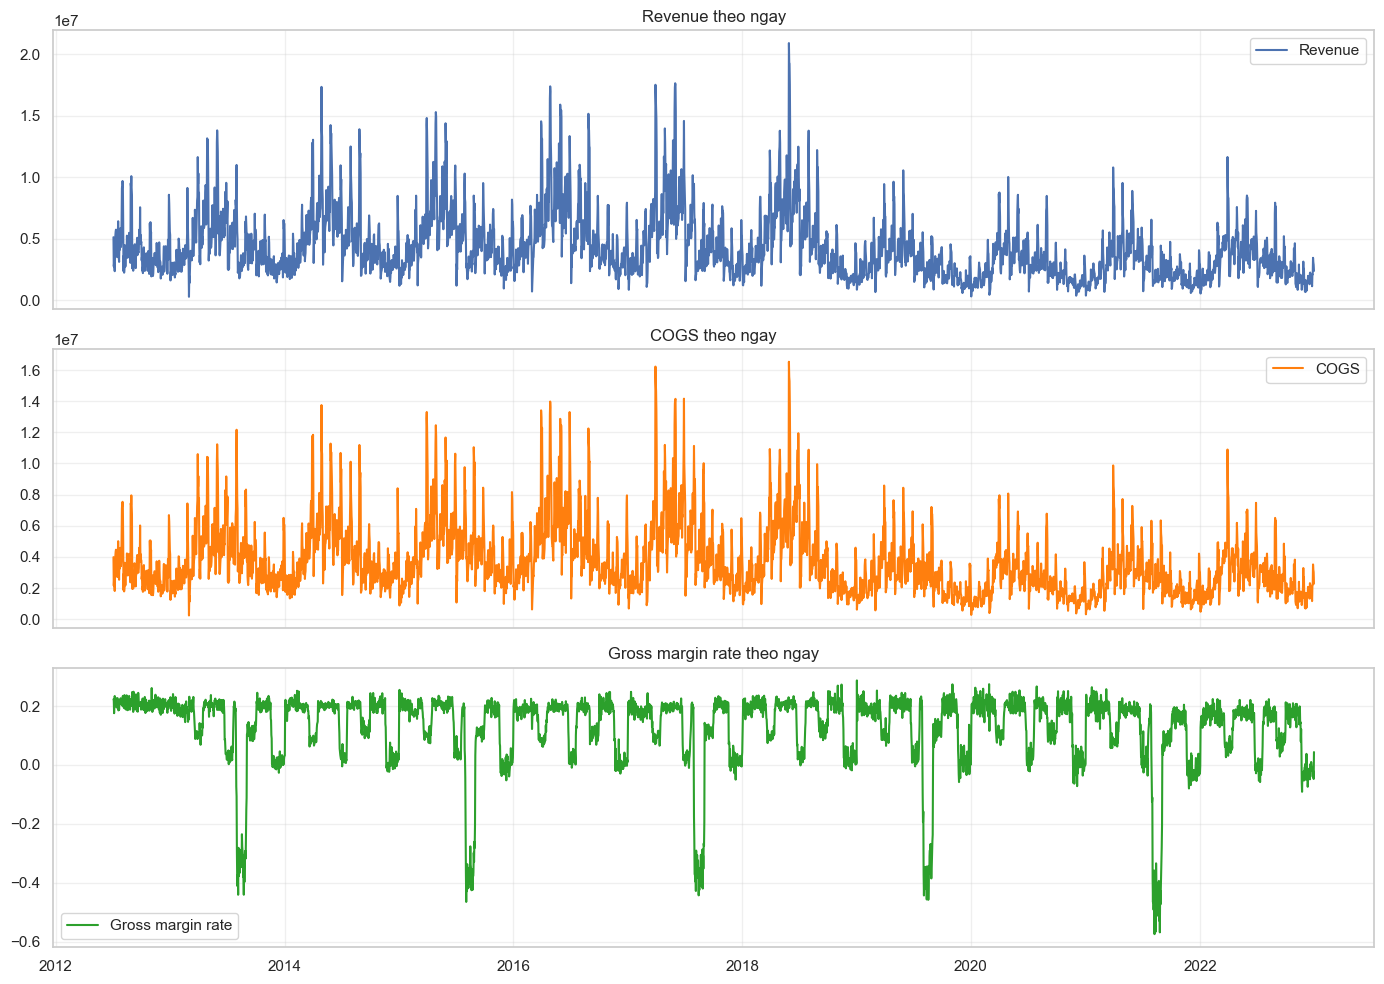

In [ ]:
if 'sales' in tables:
    sales = tables['sales'].copy()
    sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
    sales = sales.sort_values('Date')
    sales['gross_margin'] = sales['Revenue'] - sales['COGS']
    sales['gross_margin_rate'] = np.where(sales['Revenue'] != 0, sales['gross_margin'] / sales['Revenue'], np.nan)
    display(sales.describe(include='all'))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(sales['Date'], sales['Revenue'], label='Revenue')
    axes[0].set_title('Revenue theo ngay')
    axes[1].plot(sales['Date'], sales['COGS'], color='tab:orange', label='COGS')
    axes[1].set_title('COGS theo ngay')
    axes[2].plot(sales['Date'], sales['gross_margin_rate'], color='tab:green', label='Gross margin rate')
    axes[2].set_title('Gross margin rate theo ngay')
    for ax in axes:
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


,Date,Revenue,COGS,gross_margin,gross_margin_rate
0,2012-07-01,1.304068e+08,1.025165e+08,27890299.64,0.213872
1,2012-08-01,1.590892e+08,1.255853e+08,33503933.88,0.210598
2,2012-09-01,1.293071e+08,1.025962e+08,26710979.00,0.206570
3,2012-10-01,1.101857e+08,8.805481e+07,22130889.42,0.200851
4,2012-11-01,9.818630e+07,7.782008e+07,20366217.83,0.207424
5,2012-12-01,1.143226e+08,9.088911e+07,23433504.44,0.204977
6,2013-01-01,9.130868e+07,7.302380e+07,18284872.95,0.200253
7,2013-02-01,1.097831e+08,9.028688e+07,19496261.35,0.177589
8,2013-03-01,1.518347e+08,1.298978e+08,21936874.84,0.144479
9,2013-04-01,1.989269e+08,1.655820e+08,33344970.79,0.167624


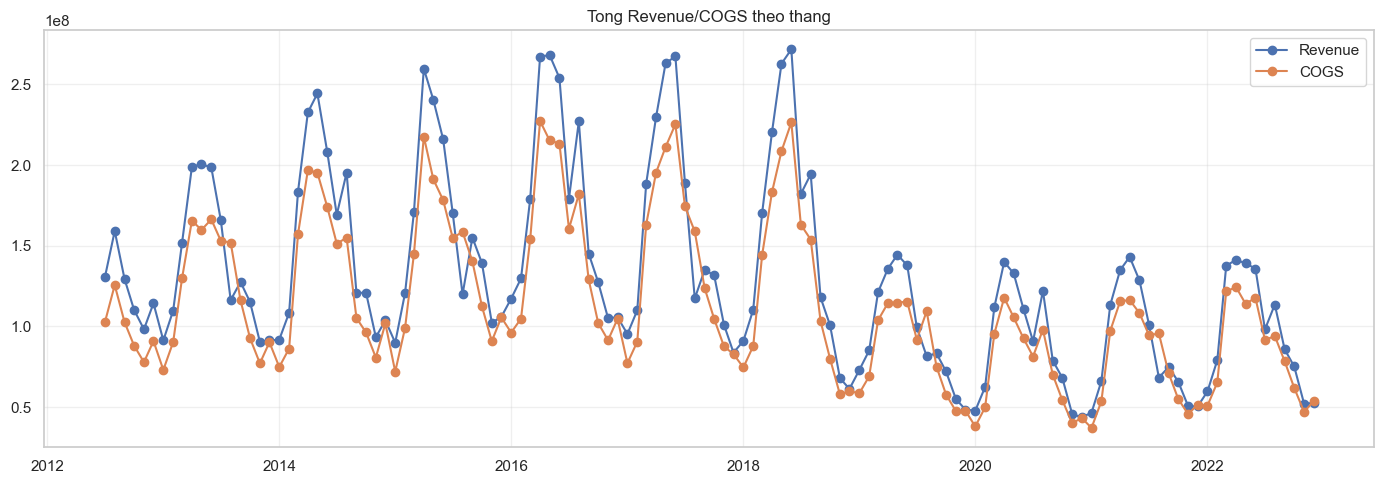

In [ ]:
if 'sales' in tables:
    monthly_sales = sales.set_index('Date').resample('MS').agg({'Revenue': 'sum', 'COGS': 'sum', 'gross_margin': 'sum'}).reset_index()
    monthly_sales['gross_margin_rate'] = monthly_sales['gross_margin'] / monthly_sales['Revenue']
    monthly_sales.to_csv(OUTPUT_DIR / '11_monthly_sales_summary.csv', index=False)
    display(monthly_sales)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly_sales['Date'], monthly_sales['Revenue'], marker='o', label='Revenue')
    ax.plot(monthly_sales['Date'], monthly_sales['COGS'], marker='o', label='COGS')
    ax.set_title('Tong Revenue/COGS theo thang')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### 3.2. EDA theo order, product, return, review

Cac join ben duoi chi dung khi key phia dimension unique. Muc tieu la phan tich metric goc theo nhom nghiep vu, khong tao feature modeling.

,category,order_lines,orders,products,quantity,revenue_after_discount,avg_discount
3,Streetwear,393533,389543,877,1768826,1.255848e+10,1455.708298
2,Outdoor,259986,200454,496,1170000,2.353397e+09,544.206062
0,Casual,23991,23600,114,107469,4.402852e+08,848.784528
1,GenZ,37159,37054,111,166848,3.287102e+08,400.681388


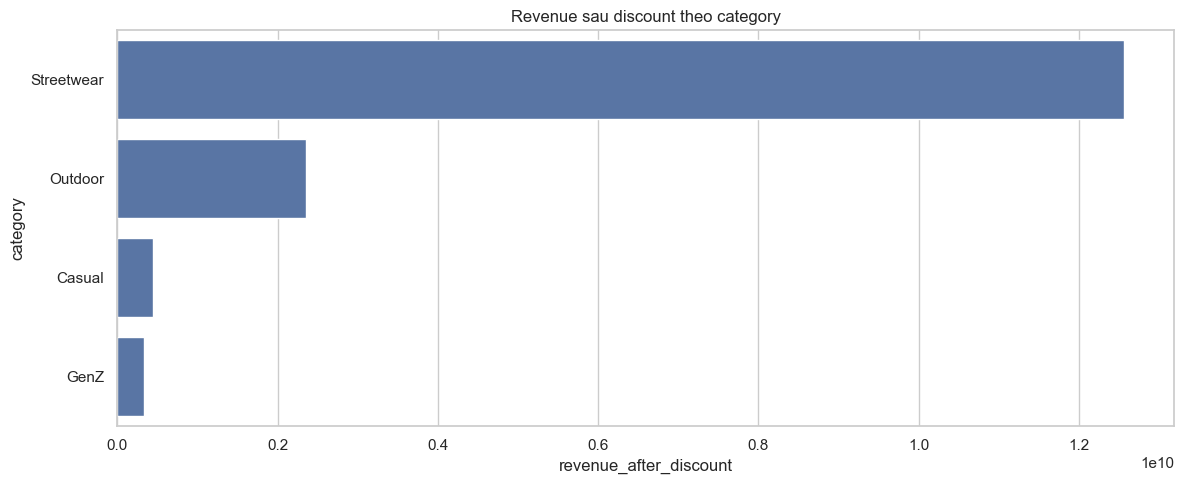

In [ ]:
if {'order_items', 'products'}.issubset(tables):
    product_key_ok = not tables['products'].duplicated(['product_id']).any()
    if product_key_ok:
        oi_product = tables['order_items'].merge(
            tables['products'][['product_id', 'product_name', 'category', 'segment', 'price', 'cogs']],
            on='product_id',
            how='left',
            validate='many_to_one'
        )
        oi_product['line_revenue_before_discount'] = oi_product['quantity'] * oi_product['unit_price']
        oi_product['line_revenue_after_discount'] = oi_product['line_revenue_before_discount'] - oi_product['discount_amount'].fillna(0)
        by_category = oi_product.groupby('category', dropna=False).agg(
            order_lines=('order_id', 'size'),
            orders=('order_id', 'nunique'),
            products=('product_id', 'nunique'),
            quantity=('quantity', 'sum'),
            revenue_after_discount=('line_revenue_after_discount', 'sum'),
            avg_discount=('discount_amount', 'mean'),
        ).reset_index().sort_values('revenue_after_discount', ascending=False)
        by_category.to_csv(OUTPUT_DIR / '12_order_item_by_category.csv', index=False)
        display(by_category)

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=by_category.head(15), x='revenue_after_discount', y='category', ax=ax)
        ax.set_title('Revenue sau discount theo category')
        plt.tight_layout()
        plt.show()
    else:
        print('Khong join products vi product_id khong unique.')


,order_date,orders,customers
0,2012-07-04,162,161
1,2012-07-05,97,97
2,2012-07-06,93,93
3,2012-07-07,73,73
4,2012-07-08,88,87


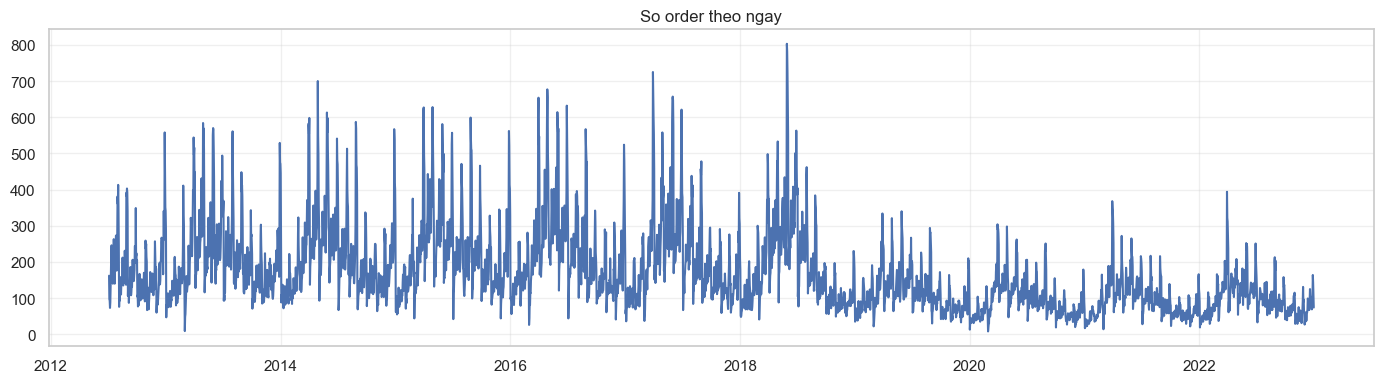

,count,pct
order_status,,
delivered,516716,0.798702
cancelled,59462,0.091912
returned,36142,0.055866
shipped,13773,0.021289
paid,13577,0.020986
created,7275,0.011245


,count,pct
payment_method,,
credit_card,356352,0.550823
paypal,97018,0.149963
cod,96681,0.149442
apple_pay,64763,0.100106
bank_transfer,32131,0.049666


,count,pct
device_type,,
mobile,291482,0.450551
desktop,258855,0.400119
tablet,96608,0.149330


,count,pct
order_source,,
organic_search,181495,0.280542
paid_search,141652,0.218955
social_media,129710,0.200496
email_campaign,77572,0.119905
referral,64565,0.099800
direct,51951,0.080302


In [ ]:
if 'orders' in tables:
    orders = tables['orders'].copy()
    orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
    orders_daily = orders.groupby('order_date').agg(
        orders=('order_id', 'nunique'),
        customers=('customer_id', 'nunique')
    ).reset_index().sort_values('order_date')
    orders_daily.to_csv(OUTPUT_DIR / '13_orders_daily.csv', index=False)
    display(orders_daily.head())

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(orders_daily['order_date'], orders_daily['orders'])
    ax.set_title('So order theo ngay')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    for col in ['order_status', 'payment_method', 'device_type', 'order_source']:
        if col in orders.columns:
            display(orders[col].value_counts(dropna=False).to_frame('count').assign(pct=lambda x: x['count'] / len(orders)).head(20))


,return_reason,return_events,return_quantity,refund_amount
4,wrong_size,13967,38042,1.766872e+08
1,defective,8020,22274,1.035991e+08
3,not_as_described,7035,19358,9.065319e+07
0,changed_mind,6931,19144,8.972176e+07
2,late_delivery,3986,10768,4.993721e+07


,count,pct
rating,,
1,5772,0.050832
2,9095,0.080096
3,17016,0.149853
4,36412,0.320666
5,45256,0.398552


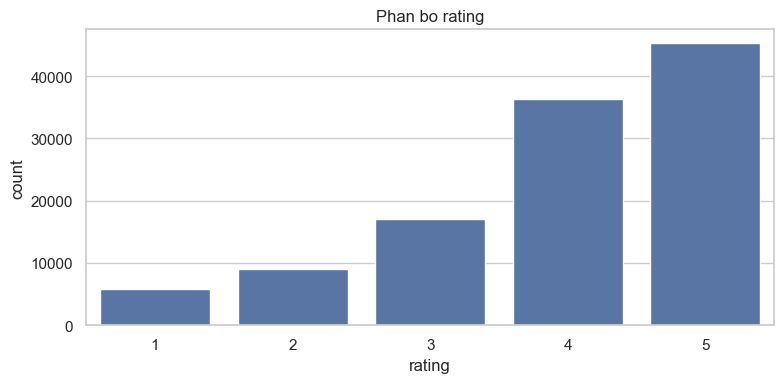

In [ ]:
if 'returns' in tables:
    returns = tables['returns'].copy()
    returns['return_date'] = pd.to_datetime(returns['return_date'], errors='coerce')
    return_reason = returns.groupby('return_reason', dropna=False).agg(
        return_events=('return_id', 'nunique'),
        return_quantity=('return_quantity', 'sum'),
        refund_amount=('refund_amount', 'sum'),
    ).reset_index().sort_values('refund_amount', ascending=False)
    return_reason.to_csv(OUTPUT_DIR / '14_return_reason_summary.csv', index=False)
    display(return_reason)

if 'reviews' in tables:
    reviews = tables['reviews'].copy()
    rating_summary = reviews['rating'].value_counts(dropna=False).sort_index().to_frame('count')
    rating_summary['pct'] = rating_summary['count'] / len(reviews)
    rating_summary.to_csv(OUTPUT_DIR / '15_rating_distribution.csv')
    display(rating_summary)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(data=reviews, x='rating', ax=ax)
    ax.set_title('Phan bo rating')
    plt.tight_layout()
    plt.show()


### 3.3. EDA traffic va inventory

Traffic va inventory co the la bang phu tro cho target theo ngay. Can xem do day du theo thoi gian va cac bat thuong lon truoc khi dung ve sau.

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
count,3652,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652
unique,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,organic_search
freq,NaN,NaN,NaN,NaN,NaN,NaN,1090
mean,2017-12-31 12:00:00,25041.768072,19031.404436,108615.224535,0.004487,210.283242,NaN
min,2013-01-01 00:00:00,7973.000000,6136.000000,30451.000000,0.003200,100.100000,NaN
25%,2015-07-02 18:00:00,17099.250000,12915.000000,72982.000000,0.003848,156.700000,NaN
50%,2017-12-31 12:00:00,23633.500000,17924.000000,101010.500000,0.004450,209.200000,NaN
75%,2020-07-01 06:00:00,31782.750000,24191.750000,138086.000000,0.005160,266.200000,NaN
max,2022-12-31 00:00:00,50947.000000,40430.000000,275560.000000,0.005800,319.900000,NaN


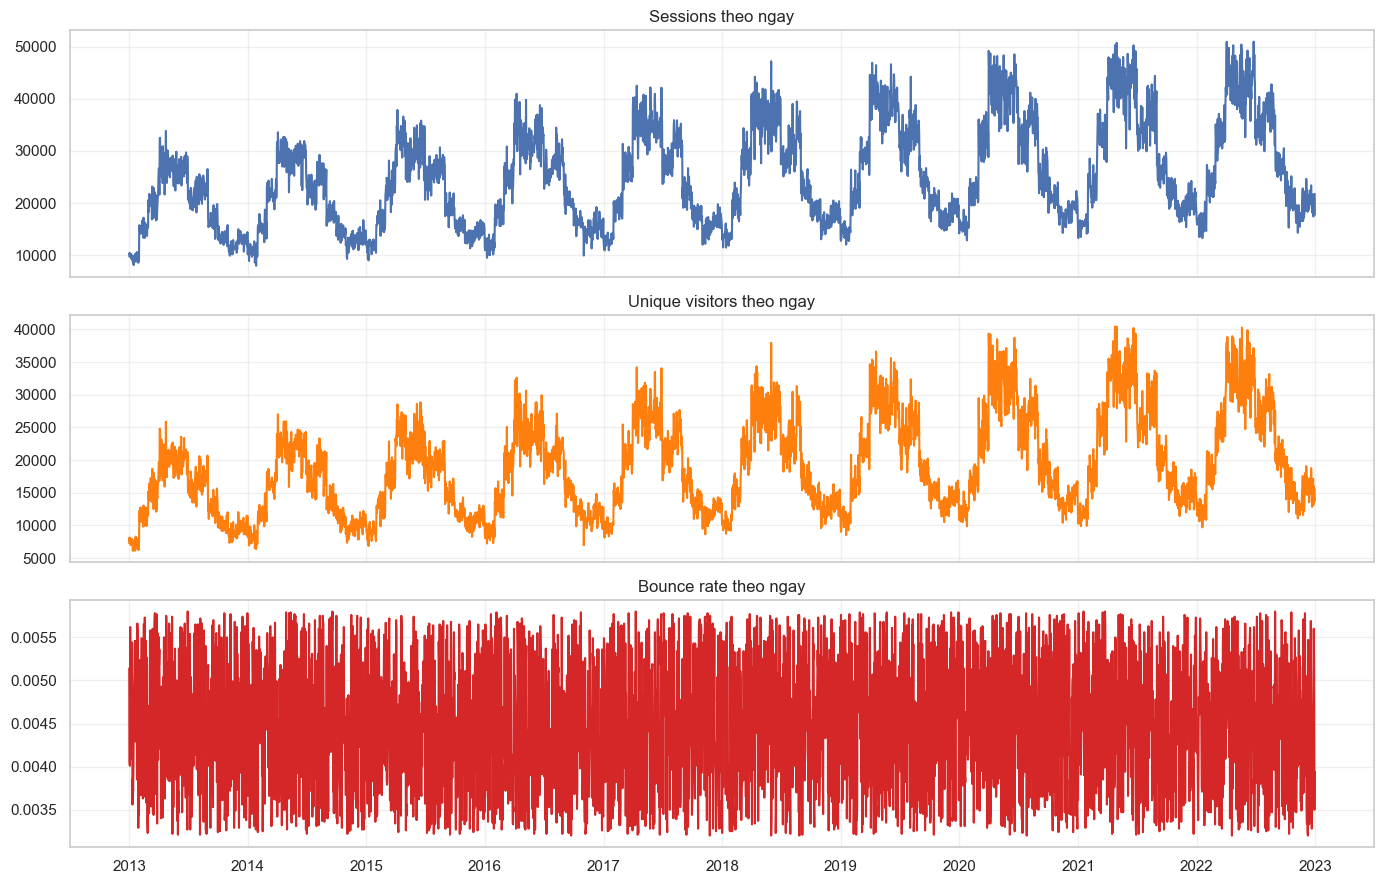

,snapshot_date,products,stock_on_hand,units_sold,stockout_days,avg_fill_rate
0,2012-07-01,395,23698,7451,402,0.966075
1,2012-08-01,423,26249,9983,699,0.944919
2,2012-09-01,424,27519,7303,636,0.950001
3,2012-10-01,437,29194,6622,621,0.952631
4,2012-11-01,411,30134,6251,495,0.959855
5,2012-12-01,449,32823,10814,666,0.950556
6,2013-01-01,423,33545,5339,431,0.966037
7,2013-02-01,443,35056,7007,584,0.956056
8,2013-03-01,455,36809,8934,587,0.956995
9,2013-04-01,479,39336,13092,674,0.953099


In [ ]:
if 'web_traffic' in tables:
    traffic = tables['web_traffic'].copy()
    traffic['date'] = pd.to_datetime(traffic['date'], errors='coerce')
    display(traffic.describe(include='all'))
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(traffic['date'], traffic['sessions'])
    axes[0].set_title('Sessions theo ngay')
    axes[1].plot(traffic['date'], traffic['unique_visitors'], color='tab:orange')
    axes[1].set_title('Unique visitors theo ngay')
    axes[2].plot(traffic['date'], traffic['bounce_rate'], color='tab:red')
    axes[2].set_title('Bounce rate theo ngay')
    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'inventory' in tables:
    inventory = tables['inventory'].copy()
    inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], errors='coerce')
    inv_monthly = inventory.groupby(pd.Grouper(key='snapshot_date', freq='MS')).agg(
        products=('product_id', 'nunique'),
        stock_on_hand=('stock_on_hand', 'sum'),
        units_sold=('units_sold', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        avg_fill_rate=('fill_rate', 'mean'),
    ).reset_index()
    inv_monthly.to_csv(OUTPUT_DIR / '16_inventory_monthly_summary.csv', index=False)
    display(inv_monthly.head(24))


## 4. Ket luan tam thoi can viet sau khi chay notebook

Sau khi chay xong, hay dien cac cau tra loi sau vao report:

1. Grain cua tung bang co dung voi gia thuyet khong?
2. Bang/key nao co duplicate lam rui ro join?
3. Missing nao la loi, missing nao co the co y nghia nghiep vu?
4. Rule gia tri nao bi vi pham va anh huong den metric nao?
5. Date range co day du khong, co dut doan hoac bat thuong khong?
6. Join nao an toan, join nao can xu ly truoc khi dung?
7. Insight EDA nao lien quan truc tiep den target/metric chinh?
8. Van de nao nen dua sang Data Preparation de clean hoac xu ly tiep?
